# Ejecucion de Ordenes y Costes

Implementacion de la simulacion de ordenes con reglas de ejecucion y costes:
- Ventas a OPEN en el dia de rebalanceo
- Compras a CLOSE en el mismo dia
- Comision 0.23% con minimo 23 USD por orden
- Si un activo deja de cotizar, se vende a CLOSE del ultimo dia disponible y queda en liquidez


In [39]:
import numpy as np
import pandas as pd
import yfinance as yf

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 50)

In [40]:
# Cargar seleccion de activos (20 symbols por fecha)
selection = pd.read_csv('seleccion_momentum.csv')
selection['date'] = pd.to_datetime(selection['date'])

required_cols = {'date', 'symbol', 'sector', 'weight', 'open', 'close'}
missing_cols = required_cols - set(selection.columns)
if missing_cols:
    raise ValueError(f'Faltan columnas en seleccion_momentum.csv: {sorted(missing_cols)}')

selection = selection.dropna(subset=['date', 'symbol', 'open', 'close', 'weight']).copy()
selection['open'] = pd.to_numeric(selection['open'], errors='coerce')
selection['close'] = pd.to_numeric(selection['close'], errors='coerce')
selection['weight'] = pd.to_numeric(selection['weight'], errors='coerce')
selection = selection.dropna(subset=['open', 'close', 'weight'])

# Garantizar un registro por fecha y symbol
selection = selection.sort_values(['date', 'score'], ascending=[True, False]).drop_duplicates(['date', 'symbol'])

counts = selection.groupby('date')['symbol'].size()
print('Fechas:', selection['date'].nunique())
print('Activos por fecha (min/max):', counts.min(), '/', counts.max())
selection.head()

Fechas: 133
Activos por fecha (min/max): 20 / 20


,date,rank,sector,symbol,score,weight,open,close
0,2015-01-31,1,Information Technology,SWKS,2.616581,0.05,67.571350,66.807150
1,2015-01-31,2,Information Technology,ENPH,2.540986,0.05,12.850000,12.390000
2,2015-01-31,3,Industrials,LUV,2.414277,0.05,40.923310,39.898903
3,2015-01-31,4,Industrials,AXON,2.378431,0.05,27.520000,27.010000
4,2015-01-31,5,Information Technology,PANW,2.109523,0.05,21.421644,21.064978


In [41]:
# Precios de mercado diarios para ejecucion (universo completo)
market_raw = pd.read_pickle('sp500_history_filtered.pkl').copy()
market_cols = ['date', 'symbol', 'open', 'close', 'sector', 'in_sp500']
available_cols = [c for c in market_cols if c in market_raw.columns]
market = market_raw[available_cols].copy()

if 'in_sp500' not in market.columns:
    market['in_sp500'] = 1

market['date'] = pd.to_datetime(market['date'])
market['open'] = pd.to_numeric(market['open'], errors='coerce')
market['close'] = pd.to_numeric(market['close'], errors='coerce')
market['in_sp500'] = pd.to_numeric(market['in_sp500'], errors='coerce').fillna(0).astype(int)
market = market.dropna(subset=['date', 'symbol', 'open', 'close'])

# Un registro por date+symbol
market = market.sort_values(['date', 'symbol']).drop_duplicates(['date', 'symbol'], keep='last')

print('Rango precios mercado:', market['date'].min().date(), '->', market['date'].max().date())
print('Symbols con precio:', market['symbol'].nunique())
market.head()



Rango precios mercado: 2013-01-02 -> 2026-01-30
Symbols con precio: 860


,date,symbol,open,close,sector,in_sp500
3299,2013-01-02,A,27.011116,26.825365,Health Care,1
10798,2013-01-02,AABA-201910,5.506497,5.473785,Consumer Discretionary,1
23155,2013-01-02,AAMRQ-201312,0.800000,0.860000,Industrials,0
26181,2013-01-02,AAP,63.962387,63.092033,Consumer Discretionary,0
35268,2013-01-02,AAPL,16.757126,16.612194,Information Technology,1


In [42]:
# Estructuras auxiliares para consultas rapidas de precios por symbol
prices_by_symbol = {}
for sym, g in market.groupby('symbol', sort=False):
    cols = ['date', 'open', 'close', 'in_sp500'] if 'in_sp500' in g.columns else ['date', 'open', 'close']
    prices_by_symbol[sym] = g[cols].set_index('date').sort_index()

all_prices = market[['date', 'symbol', 'open', 'close']].copy()
all_prices = all_prices.sort_values(['symbol', 'date'])
all_prices.head()



,date,symbol,open,close
3299,2013-01-02,A,27.011116,26.825365
3300,2013-01-03,A,26.863794,26.921442
3301,2013-01-04,A,26.991901,27.453083
3302,2013-01-07,A,27.286543,27.254519
3303,2013-01-08,A,27.203276,27.036737


In [43]:
# Mapear fecha de rebalanceo (etiqueta fin de mes) a ultimo dia habil real de mercado
selection['rebalance_date'] = pd.to_datetime(selection['date'])

# Regla de periodo: desde enero 2015 hasta la ultima fecha del dataset
auto_end_period = market['date'].max().to_period('M')
start_period = pd.Period('2015-01', freq='M')
end_period = auto_end_period

selection = selection[
    (selection['rebalance_date'].dt.to_period('M') >= start_period) &
    (selection['rebalance_date'].dt.to_period('M') <= end_period)
].copy()

# Validar cobertura mensual completa en el periodo requerido
expected_months = pd.period_range(start=start_period, end=end_period, freq='M')
available_months = set(selection['rebalance_date'].dt.to_period('M').unique())
missing_months = [m for m in expected_months if m not in available_months]
if missing_months:
    preview = ', '.join(str(m) for m in missing_months[:6])
    raise ValueError(
        f'Faltan meses en seleccion_momentum.csv para cumplir el periodo {start_period} a {end_period}. '
        f'Ejemplos faltantes: {preview}'
    )

# Validar 20 activos por rebalanceo
counts = selection.groupby('rebalance_date')['symbol'].nunique()
bad_counts = counts[counts != 20]
if not bad_counts.empty:
    raise ValueError(f'Hay rebalanceos con numero de activos distinto de 20. Ejemplos: {bad_counts.head().to_dict()}')

last_trade_by_month = (
    market.groupby(market['date'].dt.to_period('M'))['date']
          .max()
)

selection['trade_date'] = selection['rebalance_date'].dt.to_period('M').map(last_trade_by_month)
selection = selection.dropna(subset=['trade_date']).copy()
selection['trade_date'] = pd.to_datetime(selection['trade_date'])

missing_trade_date = selection['trade_date'].isna().sum()
if missing_trade_date > 0:
    raise ValueError(f'Hay rebalanceos sin trade_date mapeada: {missing_trade_date}')

print('Primer rebalanceo (label/exec):', selection['rebalance_date'].min().date(), '/', selection['trade_date'].min().date())
print('Ultimo rebalanceo (label/exec):', selection['rebalance_date'].max().date(), '/', selection['trade_date'].max().date())
selection.head(20)



Primer rebalanceo (label/exec): 2015-01-31 / 2015-01-30
Ultimo rebalanceo (label/exec): 2026-01-31 / 2026-01-30


,date,rank,sector,symbol,score,weight,open,close,rebalance_date,trade_date
0,2015-01-31,1,Information Technology,SWKS,2.616581,0.05,67.571350,66.807150,2015-01-31,2015-01-30
1,2015-01-31,2,Information Technology,ENPH,2.540986,0.05,12.850000,12.390000,2015-01-31,2015-01-30
2,2015-01-31,3,Industrials,LUV,2.414277,0.05,40.923310,39.898903,2015-01-31,2015-01-30
3,2015-01-31,4,Industrials,AXON,2.378431,0.05,27.520000,27.010000,2015-01-31,2015-01-30
4,2015-01-31,5,Information Technology,PANW,2.109523,0.05,21.421644,21.064978,2015-01-31,2015-01-30
5,2015-01-31,6,Industrials,UAL,2.006588,0.05,72.880000,69.370000,2015-01-31,2015-01-30
6,2015-01-31,7,Health Care,EW,1.958776,0.05,21.418310,20.891645,2015-01-31,2015-01-30
7,2015-01-31,8,Information Technology,SMCI,1.877320,0.05,3.762000,3.657000,2015-01-31,2015-01-30
8,2015-01-31,9,Information Technology,AVGO,1.823246,0.05,8.065107,7.880504,2015-01-31,2015-01-30
9,2015-01-31,10,Consumer Discretionary,RCL,1.800224,0.05,66.906710,66.196980,2015-01-31,2015-01-30


In [44]:
# Simulacion de ejecucion con reglas de costes, banda de rebalanceo y eventos corporativos
INITIAL_CASH = 250_000.0
FEE_RATE = 0.0023
FEE_MIN = 23.0
TARGET_WEIGHT = 0.05
N_TARGET = 20
WEIGHT_BAND = 0.001  # ?0.1%


def trade_fee(value):
    return max(FEE_RATE * value, FEE_MIN)


def affordable_buy_shares(max_shares, price, cash_available):
    shares = int(max_shares)
    while shares > 0:
        value = shares * price
        fee = trade_fee(value)
        if cash_available >= value + fee:
            return shares, value, fee
        shares -= 1
    return 0, 0.0, 0.0


holdings = {}  # symbol -> int shares
cash = float(INITIAL_CASH)
history = []
orders = []

rebalance_info = (
    selection[['rebalance_date', 'trade_date']]
    .drop_duplicates()
    .sort_values('rebalance_date')
    .itertuples(index=False)
)

prev_trade_d = None

for row_info in rebalance_info:
    rebalance_d = pd.Timestamp(row_info.rebalance_date)
    trade_d = pd.Timestamp(row_info.trade_date)

    day_sel = selection[selection['rebalance_date'] == rebalance_d].copy()
    if 'score' in day_sel.columns:
        day_sel = day_sel.sort_values('score', ascending=False)
    day_sel = day_sel.head(N_TARGET)

    if day_sel['symbol'].nunique() != N_TARGET:
        raise ValueError(f'{rebalance_d.date()}: se esperaban {N_TARGET} activos y hay {day_sel["symbol"].nunique()}.')

    target_symbols = set(day_sel['symbol'])
    sector_map_today = day_sel.set_index('symbol')['sector'].to_dict()

    holdings_start = holdings.copy()

    # Eventos entre rebalanceos: salida de SP500 o delisting
    if prev_trade_d is not None:
        for sym in list(holdings.keys()):
            px_sym = prices_by_symbol.get(sym)
            if px_sym is None:
                continue

            window = px_sym.loc[(px_sym.index > prev_trade_d) & (px_sym.index <= trade_d)]
            if window.empty:
                continue

            exit_sp500_date = None
            if 'in_sp500' in window.columns:
                out_rows = window[window['in_sp500'] <= 0]
                if not out_rows.empty:
                    exit_sp500_date = out_rows.index.min()

            delist_date = None
            if trade_d not in window.index:
                delist_date = window.index.max()

            event_date = None
            event_side = None
            if exit_sp500_date is not None and delist_date is not None:
                if exit_sp500_date <= delist_date:
                    event_date = exit_sp500_date
                    event_side = 'SELL_EXIT_SP500'
                else:
                    event_date = delist_date
                    event_side = 'SELL_DELIST'
            elif exit_sp500_date is not None:
                event_date = exit_sp500_date
                event_side = 'SELL_EXIT_SP500'
            elif delist_date is not None:
                event_date = delist_date
                event_side = 'SELL_DELIST'

            if event_date is not None:
                exit_px = float(window.loc[event_date, 'close'])
                shares = int(holdings.get(sym, 0))
                if shares <= 0:
                    continue

                value = shares * exit_px
                fee = trade_fee(value)
                cash += value - fee
                orders.append({
                    'date': event_date,
                    'rebalance_date': rebalance_d,
                    'trade_date': trade_d,
                    'symbol': sym,
                    'sector': sector_map_today.get(sym),
                    'side': event_side,
                    'shares': shares,
                    'price': exit_px,
                    'value': value,
                    'fee': fee,
                })
                del holdings[sym]

    # Valor de cartera a OPEN del trade day
    port_value_open = cash
    day_open = {}
    day_close = {}

    for sym, sh in holdings.items():
        px_sym = prices_by_symbol.get(sym)
        if px_sym is None:
            continue

        if trade_d in px_sym.index:
            px_o = float(px_sym.loc[trade_d, 'open'])
            px_c = float(px_sym.loc[trade_d, 'close'])
            day_open[sym] = px_o
            day_close[sym] = px_c
            port_value_open += sh * px_o
        else:
            last_rows = px_sym.loc[px_sym.index <= trade_d]
            if not last_rows.empty:
                port_value_open += sh * float(last_rows.iloc[-1]['close'])

    if port_value_open <= 0:
        raise ValueError(f'Valor de cartera no positivo en {trade_d.date()}.')

    target_values = {sym: port_value_open * TARGET_WEIGHT for sym in target_symbols}

    open_weight_snapshot = {}
    for sym, sh in holdings.items():
        if sym in day_open:
            open_weight_snapshot[sym] = (sh * day_open[sym]) / port_value_open
        else:
            open_weight_snapshot[sym] = 0.0

    # 1) Ventas a OPEN (salidas del top 20 y rebalanceo a la baja)
    for sym in list(holdings.keys()):
        if sym not in day_open:
            continue

        current_shares = int(holdings[sym])
        if current_shares <= 0:
            del holdings[sym]
            continue

        px_open = day_open[sym]
        shares_to_sell = 0
        side = None

        if sym not in target_symbols:
            shares_to_sell = current_shares
            side = 'SELL_EXIT_TOP20'
        else:
            w_open = open_weight_snapshot.get(sym, 0.0)
            if w_open > TARGET_WEIGHT + WEIGHT_BAND:
                target_shares_open = int(target_values[sym] / px_open)
                shares_to_sell = max(current_shares - target_shares_open, 0)
                side = 'SELL_REBAL'

        if shares_to_sell > 0:
            sell_value = shares_to_sell * px_open
            fee = trade_fee(sell_value)
            cash += sell_value - fee
            holdings[sym] = current_shares - shares_to_sell
            orders.append({
                'date': trade_d,
                'rebalance_date': rebalance_d,
                'trade_date': trade_d,
                'symbol': sym,
                'sector': sector_map_today.get(sym),
                'side': side,
                'shares': shares_to_sell,
                'price': px_open,
                'value': sell_value,
                'fee': fee,
            })
            if holdings[sym] <= 0:
                del holdings[sym]

    # Completar precios CLOSE para seleccionados
    for sym in target_symbols:
        if sym in day_close:
            continue
        px_sym = prices_by_symbol.get(sym)
        if px_sym is not None and trade_d in px_sym.index:
            day_close[sym] = float(px_sym.loc[trade_d, 'close'])

    # 2) Compras a CLOSE (entradas y rebalanceo al alza)
    for _, row_sel in day_sel.iterrows():
        sym = row_sel['symbol']
        px_close = day_close.get(sym)
        if px_close is None or px_close <= 0:
            continue

        was_held_at_open = sym in holdings_start
        w_open = open_weight_snapshot.get(sym, 0.0) if was_held_at_open else 0.0
        need_buy = (not was_held_at_open) or (w_open < TARGET_WEIGHT - WEIGHT_BAND)
        if not need_buy:
            continue

        current_shares = int(holdings.get(sym, 0))
        target_shares_close = int(target_values[sym] / px_close)
        raw_buy_shares = max(target_shares_close - current_shares, 0)
        if raw_buy_shares <= 0:
            continue

        buy_shares, buy_value, fee = affordable_buy_shares(raw_buy_shares, px_close, cash)
        if buy_shares <= 0:
            continue

        cash -= buy_value + fee
        holdings[sym] = current_shares + buy_shares
        orders.append({
            'date': trade_d,
            'rebalance_date': rebalance_d,
            'trade_date': trade_d,
            'symbol': sym,
            'sector': row_sel['sector'],
            'side': 'BUY_NEW' if not was_held_at_open else 'BUY_REBAL',
            'shares': buy_shares,
            'price': px_close,
            'value': buy_value,
            'fee': fee,
        })

    # Valor de cartera al cierre del trade day
    close_value = cash
    for sym, sh in holdings.items():
        px_sym = prices_by_symbol.get(sym)
        if px_sym is None:
            continue
        if trade_d in px_sym.index:
            close_value += sh * float(px_sym.loc[trade_d, 'close'])
        else:
            last_rows = px_sym.loc[px_sym.index <= trade_d]
            if not last_rows.empty:
                close_value += sh * float(last_rows.iloc[-1]['close'])

    history.append({
        'date': rebalance_d,
        'trade_date': trade_d,
        'portfolio_value': close_value,
        'cash': cash,
        'num_positions': len(holdings),
    })

    prev_trade_d = trade_d

history_df = pd.DataFrame(history)
orders_df = pd.DataFrame(orders)
history_df.head()



,date,trade_date,portfolio_value,cash,num_positions
0,2015-01-31,2015-01-30,249426.421008,44.250780,20
1,2015-02-28,2015-02-27,258704.456730,12381.876869,19
2,2015-03-31,2015-03-31,263213.690286,13246.433977,19
3,2015-04-30,2015-04-30,252796.959729,6.842679,20
4,2015-05-31,2015-05-29,261391.623592,46.636900,20


In [45]:
# Coste de transaccion por rebalanceo
from pathlib import Path

fees_by_rebalance = (
    orders_df.groupby('rebalance_date', as_index=False)['fee']
             .sum()
             .rename(columns={'rebalance_date': 'date', 'fee': 'txn_cost'})
)

# Incluir costes por rebalanceo dentro de history_df
history_df = history_df.copy()
history_df['date'] = pd.to_datetime(history_df['date'])
fees_aux = fees_by_rebalance.copy()
fees_aux['date'] = pd.to_datetime(fees_aux['date'])
history_df = history_df.drop(columns=['txn_cost'], errors='ignore')
history_df = history_df.merge(fees_aux[['date', 'txn_cost']], on='date', how='left')
history_df['txn_cost'] = pd.to_numeric(history_df['txn_cost'], errors='coerce').fillna(0.0)

# Persistir history_df para reutilizarlo desde resultadosRobustez
out_dir = Path('resultadosEjecucion1')
out_dir.mkdir(parents=True, exist_ok=True)
history_pickle_path = out_dir / 'history_df.pkl'
history_df.to_pickle(history_pickle_path)

print('history_df guardado en:', history_pickle_path.as_posix())
print('Coste total de transacciones:', f"{fees_by_rebalance['txn_cost'].sum():.2f}")
print('Ordenes ejecutadas:', len(orders_df))
print('Valor final cartera:', f"{history_df['portfolio_value'].iloc[-1]:.2f}" if len(history_df) else np.nan)
print('Posiciones por rebalanceo (min/max):', history_df['num_positions'].min(), '/', history_df['num_positions'].max())

fees_by_rebalance.head()



history_df guardado en: resultadosEjecucion1/history_df.pkl
Coste total de transacciones: 152255.22
Ordenes ejecutadas: 4499
Valor final cartera: 518420.95
Posiciones por rebalanceo (min/max): 19 / 21


,date,txn_cost
0,2015-01-31,573.578992
1,2015-02-28,811.105805
2,2015-03-31,734.538423
3,2015-04-30,757.020624
4,2015-05-31,987.152867


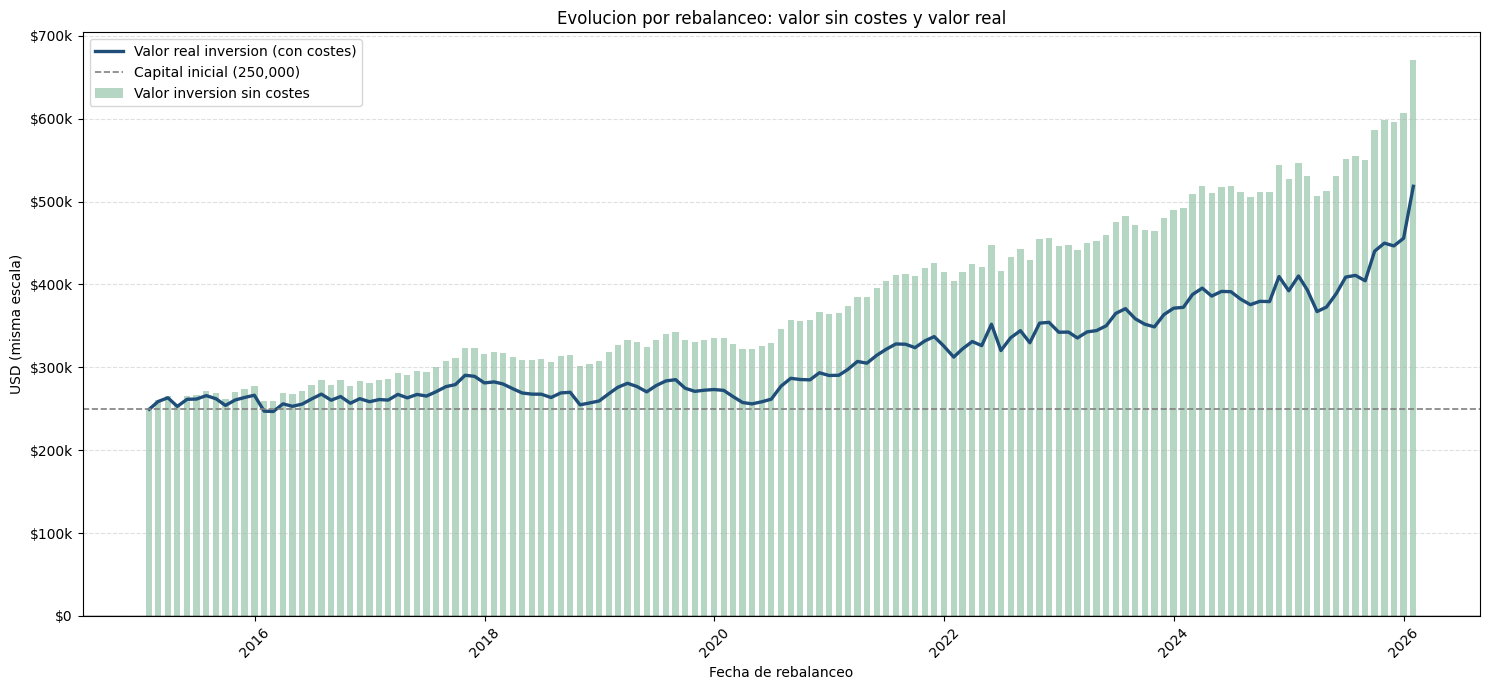

Resumen rebalanceos:
Min valor sin costes: 250,000.00
Valor final sin costes: 670,676.17
Valor final real (con costes): 518,420.95
Coste total acumulado: 152,255.22


In [ ]:
# Visualizacion por rebalanceo: valor sin costes y valor real
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


def usd_compact(x, pos):
    ax = abs(x)
    if ax >= 1_000_000:
        return f'${x/1_000_000:,.1f}M'
    if ax >= 1_000:
        return f'${x/1_000:,.0f}k'
    return f'${x:,.0f}'


plot_df = history_df[['date', 'portfolio_value', 'txn_cost']].copy()
plot_df['date'] = pd.to_datetime(plot_df['date'])
plot_df = plot_df.sort_values('date').reset_index(drop=True)

initial_capital = float(globals().get('INITIAL_CASH', 250_000.0))
plot_df['txn_cost'] = pd.to_numeric(plot_df['txn_cost'], errors='coerce').fillna(0.0)

# Valor sin costes = valor real + costes acumulados
plot_df['cum_txn_cost'] = plot_df['txn_cost'].cumsum()
plot_df['value_no_cost'] = plot_df['portfolio_value'] + plot_df['cum_txn_cost']
plot_df['value_real'] = plot_df['portfolio_value']

fig, ax = plt.subplots(figsize=(15, 7))
bar_width_days = 20

# Barras verdes: valor de inversion sin costes
ax.bar(
    plot_df['date'],
    plot_df['value_no_cost'],
    width=bar_width_days,
    color='#4c9f70',
    alpha=0.35,
    label='Valor inversion sin costes'
)

# Linea azul: valor real con costes
ax.plot(
    plot_df['date'],
    plot_df['value_real'],
    color='#1f4e79',
    linewidth=2.4,
    label='Valor real inversion (con costes)'
)

ax.axhline(initial_capital, color='gray', linestyle='--', linewidth=1.2, label='Capital inicial (250,000)')
ax.axhline(0, color='black', linewidth=1.0)

# Misma escala en un unico eje Y
y_min = 0
y_max = max(plot_df['value_no_cost'].max(), plot_df['value_real'].max(), initial_capital) * 1.05
ax.set_ylim(y_min, y_max)

ax.set_title('Evolucion por rebalanceo: valor sin costes y valor real')
ax.set_xlabel('Fecha de rebalanceo')
ax.set_ylabel('USD (misma escala)')
ax.yaxis.set_major_formatter(FuncFormatter(usd_compact))
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
ax.legend(loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('Resumen rebalanceos:')
print('Min valor sin costes:', f"{plot_df['value_no_cost'].min():,.2f}")
print('Valor final sin costes:', f"{plot_df['value_no_cost'].iloc[-1]:,.2f}")
print('Valor final real (con costes):', f"{plot_df['value_real'].iloc[-1]:,.2f}")
print('Coste total acumulado:', f"{plot_df['txn_cost'].sum():,.2f}")

